# 上市公司资本结构影响因素分析 （exP03）
- 姓名：谢婧怡  学号：25210094

本 Notebook 使用 Stata 代码直接完成数据清洗、面板构建与 M1–M6 实证模型估计，并导出结果表和图。

In [ ]:
display as txt "PWD: `c(pwd)'"
display as txt "exists ./data/raw/balance_sheet.csv = " fileexists("data/raw/balance_sheet.csv")
display as txt "exists ../data/raw/balance_sheet.csv = " fileexists("../data/raw/balance_sheet.csv")
display as txt "exists ../../data/raw/balance_sheet.csv = " fileexists("../../data/raw/balance_sheet.csv")

PWD: c:\Users\Lenovo\Documents\GitHub\dshw--panel\notebooks
exists ./data/raw/balance_sheet.csv = 0
exists ../data/raw/balance_sheet.csv = 1
exists ../../data/raw/balance_sheet.csv = 0


In [15]:

clear all
version 18
set more off
set varabbrev off

* ------------------------------
* 0. 路径自动探测
* ------------------------------
local ROOT ""
if fileexists("data/raw/balance_sheet.csv") local ROOT "."
else if fileexists("../data/raw/balance_sheet.csv") local ROOT ".."
else if fileexists("../../data/raw/balance_sheet.csv") local ROOT "../.."
else {
    di as err "Cannot find data/raw/balance_sheet.csv. Please check working directory."
    exit 601
}

global RAW "`ROOT'/data/raw"
global CLEAN "`ROOT'/data/clean"
global OUT "`ROOT'/output"
global FIG "$OUT/figures"

di "RAW: $RAW"
di "CLEAN: $CLEAN"
di "OUT: $OUT"

cap mkdir "$CLEAN"
cap mkdir "$OUT"
cap mkdir "$FIG"



RAW: ../data/raw
CLEAN: ../data/clean
OUT: ../output


In [16]:

* 用于将任意命名的股票代码变量转换为统一的数值型 stkcd
capture program drop mk_stkcd
program define mk_stkcd
    syntax , IDVAR(name)
    capture confirm string variable `idvar'
    if _rc {
        tostring `idvar', gen(stkcd_str) format(%12.0f) force
    }
    else {
        gen str12 stkcd_str = trim(`idvar')
    }
    replace stkcd_str = trim(stkcd_str)
    destring stkcd_str, gen(stkcd) force
    drop stkcd_str
end

In [18]:

* ==============================
* 3.1 资产负债表 (balance_sheet.csv)
* ==============================
import delimited "$RAW/balance_sheet.csv", varnames(1) clear case(preserve) encoding(utf-8)
mk_stkcd, idvar(Stkcd)
gen double accper = date(Accper, "YMD")
format accper %td
gen int year = year(accper)
keep if inlist(upper(trim(Typrep)), "A")        // 只保留年报
keep if month(accper) == 12                     // 年末数据

rename A004000000 total_assets
rename A003000000 total_liab
rename A002000000 fixed_assets_net

keep stkcd year total_assets total_liab fixed_assets_net
duplicates drop stkcd year, force
save "$CLEAN/balance_ann.dta", replace

* ==============================
* 3.2 利润表 (income_stmt.csv)
* ==============================
import delimited "$RAW/income_stmt.csv", varnames(1) clear case(preserve) encoding(utf-8)
mk_stkcd, idvar(Stkcd)
gen double accper = date(Accper, "YMD")
format accper %td
gen int year = year(accper)
keep if inlist(upper(trim(Typrep)), "A")
keep if month(accper) == 12

rename B001000000 net_profit
keep stkcd year net_profit
duplicates drop stkcd year, force
save "$CLEAN/income_ann.dta", replace

* ==============================
* 3.3 现金流量表 (cashflow.csv)
* ==============================
import delimited "$RAW/cashflow.csv", varnames(1) clear case(preserve) encoding(utf-8)
mk_stkcd, idvar(Stkcd)
gen double accper = date(Accper, "YMD")
format accper %td
gen int year = year(accper)
keep if inlist(upper(trim(Typrep)), "A")
keep if month(accper) == 12

capture confirm variable C001100000
if !_rc rename C001100000 depreciation
else gen double depreciation = .

keep stkcd year depreciation
duplicates drop stkcd year, force
save "$CLEAN/cashflow_ann.dta", replace

(154 vars, 296,156 obs)
stkcd_str generated as str6
(0 real changes made)
stkcd_str: all characters numeric; stkcd generated as long
(0 observations deleted)
(237,029 observations deleted)

Duplicates in terms of stkcd year

(0 observations are duplicates)
file ../data/clean/balance_ann.dta saved
(81 vars, 296,159 obs)
stkcd_str generated as str6
(0 real changes made)
stkcd_str: all characters numeric; stkcd generated as long
(0 observations deleted)
(237,030 observations deleted)

Duplicates in terms of stkcd year

(0 observations are duplicates)
file ../data/clean/income_ann.dta saved
(72 vars, 295,849 obs)
stkcd_str generated as str6
(0 real changes made)
stkcd_str: all characters numeric; stkcd generated as long
(0 observations deleted)
(236,874 observations deleted)

Duplicates in terms of stkcd year

(0 observations are duplicates)
file ../data/clean/cashflow_ann.dta saved


In [23]:

* ==============================
* 4.1 股权性质 (ownership.csv)
* ==============================
import delimited "$RAW/ownership.csv", varnames(1) clear case(preserve) encoding(utf-8)
mk_stkcd, idvar(Symbol)
gen double endd = date(EndDate, "YMD")
format endd %td
gen int year = year(endd)

* 识别国有企业（根据 EquityNature 或 EquityNatureID）
capture confirm string variable EquityNatureID
if _rc tostring EquityNatureID, replace force
capture confirm string variable EquityNature
if _rc tostring EquityNature, replace force

gen byte soe = 0
replace soe = 1 if regexm(EquityNatureID, "(^|,)1(,|$)")
replace soe = 1 if strpos(EquityNature, "国企") > 0 | strpos(EquityNature, "国有") > 0

keep stkcd year soe
duplicates drop stkcd year, force
save "$CLEAN/ownership.dta", replace

* ==============================
* 4.2 行业分类 (industry.csv)
* ==============================
import delimited "$RAW/industry.csv", varnames(1) clear case(preserve) encoding(utf-8)
mk_stkcd, idvar(Symbol)
gen double endd = date(EndDate, "YMD")
gen int year = year(endd)
rename IndustryCode ind_code
keep stkcd year ind_code
duplicates drop stkcd year, force
save "$CLEAN/industry.dta", replace

* ==============================
* 4.3 ST/PT 标记 (st_flag.csv)
* ==============================
import delimited "$RAW/st_flag.csv", varnames(1) clear case(preserve) encoding(utf-8)
mk_stkcd, idvar(Symbol)
gen double endd = date(EndDate, "YMD")
gen int year = year(endd)
capture confirm string variable LISTINGSTATE
if _rc tostring LISTINGSTATE, replace force
rename LISTINGSTATE listing_state
keep stkcd year listing_state
duplicates drop stkcd year, force
save "$CLEAN/st_flag.dta", replace

* ==============================
* 4.4 M2 增长率 (m2.csv)
* ==============================
import delimited "$RAW/m2.csv", varnames(1) clear case(preserve) encoding(utf-8)

* 确保year为数值型
destring year, replace force

* 设定时间序列（年度）
tsset year

* 计算M2增长率（百分比）
gen double m2_growth = (m2 - L.m2) / L.m2 * 100

* 仅保留所需变量
keep year m2_growth

* 保存为Stata数据文件
save "$CLEAN/m2.dta", replace

(5 vars, 55,716 obs)
stkcd_str generated as str6
(0 real changes made)
stkcd_str: all characters numeric; stkcd generated as long
(18,040 real changes made)
(0 real changes made)

Duplicates in terms of stkcd year

(0 observations are duplicates)
file ../data/clean/ownership.dta saved
(7 vars, 56,731 obs)
stkcd_str generated as str6
(0 real changes made)
stkcd_str: all characters numeric; stkcd generated as long

Duplicates in terms of stkcd year

(0 observations are duplicates)
file ../data/clean/industry.dta saved
(6 vars, 56,731 obs)
stkcd_str generated as str6
(0 real changes made)
stkcd_str: all characters numeric; stkcd generated as long

Duplicates in terms of stkcd year

(0 observations are duplicates)
file ../data/clean/st_flag.dta saved
(2 vars, 16 obs)
year already numeric; no replace

Time variable: year, 2010 to 2025
        Delta: 1 unit
(1 missing value generated)
(file ../data/clean/m2.dta not found)
file ../data/clean/m2.dta saved


In [27]:


capture restore, not

* ===== 重新加载资产负债表主文件 =====
use "$CLEAN/balance_ann.dta", clear

* ===== 合并其他数据表 =====
merge 1:1 stkcd year using "$CLEAN/income_ann.dta", nogen keep(master match)
merge 1:1 stkcd year using "$CLEAN/cashflow_ann.dta", nogen keep(master match)
merge 1:1 stkcd year using "$CLEAN/ownership.dta", nogen keep(master match)
merge 1:1 stkcd year using "$CLEAN/industry.dta", nogen keep(master match)
merge 1:1 stkcd year using "$CLEAN/st_flag.dta", nogen keep(master match)
merge m:1 year using "$CLEAN/m2.dta", nogen keep(master match)

* ===== 数值变量转换 =====
foreach v in total_assets total_liab fixed_assets_net net_profit depreciation {
    capture destring `v', replace force
}

* ===== 构造分析变量 =====
gen double lev = total_liab / total_assets if total_assets > 0
gen double npr = net_profit / total_assets if total_assets > 0
gen double size = ln(total_assets) if total_assets > 0
gen double tang = fixed_assets_net / total_assets if total_assets > 0
gen double ndts = depreciation / total_assets if total_assets > 0

* 成长性（需要滞后一期总资产）
bysort stkcd (year): gen double total_assets_lag1 = total_assets[_n-1]
gen double growth = (total_assets - total_assets_lag1) / total_assets_lag1 if total_assets_lag1 > 0

* ===== 生成行业标识与 ST 标记 =====
gen str1 ind1 = substr(ind_code, 1, 1)
gen byte is_finance = (ind1 == "J")

* 基于 listing_state 生成 st_flag（ST=1）
capture confirm string variable listing_state
if _rc tostring listing_state, replace force
gen byte st_flag = (strpos(upper(listing_state), "ST") > 0) if !missing(listing_state)

* ===== 样本筛选流程记录 =====
tempname fh
postfile `fh' str40 step long N using "$OUT/sample_counts.dta", replace

* Step 1: 初始合并样本
count
post `fh' ("1. Initial merged sample") (r(N))

* Step 2: 剔除金融业（J 开头）
drop if is_finance == 1
count
post `fh' ("2. After dropping finance (J)") (r(N))

* Step 3: 剔除曾被 ST 的公司（全样本剔除）
preserve
    keep stkcd st_flag
    bysort stkcd: egen ever_st = max(st_flag)
    keep stkcd ever_st
    duplicates drop stkcd, force
    tempfile st_keep
    save `st_keep', replace
restore

merge m:1 stkcd using `st_keep', nogen
drop if ever_st == 1
drop ever_st st_flag
count
post `fh' ("3. After dropping ST firms") (r(N))

* Step 4: 剔除 lev > 1 的观测
drop if lev > 1 & !missing(lev)
count
post `fh' ("4. After dropping lev > 1") (r(N))

* Step 5: 剔除关键变量缺失
drop if missing(lev, npr, size, tang, growth, ndts)
count
post `fh' ("5. After dropping missing core vars") (r(N))

postclose `fh'

* ===== 显示样本筛选流程表 =====
use "$OUT/sample_counts.dta", clear
list, clean noobs
export delimited using "$OUT/sample_counts.csv", replace

* ===== 重新构造一份清洗后（未缩尾）的数据供后续绘图对比 =====
use "$CLEAN/balance_ann.dta", clear
merge 1:1 stkcd year using "$CLEAN/income_ann.dta", nogen keep(master match)
merge 1:1 stkcd year using "$CLEAN/cashflow_ann.dta", nogen keep(master match)
merge 1:1 stkcd year using "$CLEAN/ownership.dta", nogen keep(master match)
merge 1:1 stkcd year using "$CLEAN/industry.dta", nogen keep(master match)
merge 1:1 stkcd year using "$CLEAN/st_flag.dta", nogen keep(master match)
merge m:1 year using "$CLEAN/m2.dta", nogen keep(master match)

foreach v in total_assets total_liab fixed_assets_net net_profit depreciation {
    capture destring `v', replace force
}

gen double lev = total_liab / total_assets if total_assets > 0
gen double npr = net_profit / total_assets if total_assets > 0
gen double size = ln(total_assets) if total_assets > 0
gen double tang = fixed_assets_net / total_assets if total_assets > 0
gen double ndts = depreciation / total_assets if total_assets > 0
bysort stkcd (year): gen double total_assets_lag1 = total_assets[_n-1]
gen double growth = (total_assets - total_assets_lag1) / total_assets_lag1 if total_assets_lag1 > 0
gen str1 ind1 = substr(ind_code, 1, 1)
gen byte is_finance = (ind1 == "J")
capture confirm string variable listing_state
if _rc tostring listing_state, replace force
gen byte st_flag = (strpos(upper(listing_state), "ST") > 0) if !missing(listing_state)

* 执行相同的筛选逻辑
drop if is_finance == 1

preserve
    keep stkcd st_flag
    bysort stkcd: egen ever_st = max(st_flag)
    keep stkcd ever_st
    duplicates drop stkcd, force
    tempfile st_keep2
    save `st_keep2', replace
restore

merge m:1 stkcd using `st_keep2', nogen
drop if ever_st == 1
drop ever_st st_flag
drop if lev > 1 & !missing(lev)
drop if missing(lev, npr, size, tang, growth, ndts)

* 保存清洗后未缩尾的数据
save "$CLEAN/sample_before_winsor.dta", replace

di _n "Sample before winsorizing saved: $CLEAN/sample_before_winsor.dta"
di "Sample counts table exported to $OUT/sample_counts.csv"

(Note: Below code run with echo to enable preserve/restore functionality.)

. capture restore, not

. use "$CLEAN/balance_ann.dta", clear

. merge 1:1 stkcd year using "$CLEAN/income_ann.dta", nogen keep(master match)

    Result                      Number of obs
    -----------------------------------------
    Not matched                             0
    Matched                            59,127  
    -----------------------------------------

. merge 1:1 stkcd year using "$CLEAN/cashflow_ann.dta", nogen keep(master match
> )

    Result                      Number of obs
    -----------------------------------------
    Not matched                           152
        from master                       152  
        from using                          0  

    Matched                            58,975  
    -----------------------------------------

. merge 1:1 stkcd year using "$CLEAN/ownership.dta", nogen keep(master match)

    Result                      Number of obs
    ----

In [28]:

use "$CLEAN/sample_before_winsor.dta", clear

* 分年度 1% 和 99% 缩尾
cap which winsor2
if _rc == 0 {
    winsor2 lev npr tang growth ndts, cuts(1 99) by(year) replace
}
else {
    * 手动缩尾备选方案
    foreach v in lev npr tang growth ndts {
        bysort year: egen p1_`v' = pctile(`v'), p(1)
        bysort year: egen p99_`v' = pctile(`v'), p(99)
        replace `v' = max(`v', p1_`v')
        replace `v' = min(`v', p99_`v')
        drop p1_`v' p99_`v'
    }
}

* 设定面板
destring stkcd, replace force
xtset stkcd year

save "$CLEAN/final_panel.dta", replace
export delimited using "$CLEAN/final_panel.csv", replace

stkcd already numeric; no replace

Panel variable: stkcd (unbalanced)
 Time variable: year, 2011 to 2025, but with gaps
         Delta: 1 unit
file ../data/clean/final_panel.dta saved
file ../data/clean/final_panel.csv saved


(Note: Below code run with echo to enable preserve/restore functionality.)

. use "$CLEAN/final_panel.dta", clear

. eststo clear

. estpost sum lev npr size tang growth ndts

             |  e(count)   e(sum_w)    e(mean)     e(Var)      e(sd) 
-------------+-------------------------------------------------------
         lev |     43026      43026   .5928382   .0391987   .1979867 
         npr |     43026      43026   .0469864   .0045643   .0675593 
        size |     43026      43026   22.23271   2.062094   1.435999 
        tang |     43026      43026   .4071628   .0391981   .1979851 
      growth |     43026      43026   .1448979   .0877847   .2962849 
        ndts |     43026      43026   .6341794   .2032427   .4508244 

             |    e(min)     e(max)     e(sum) 
-------------+---------------------------------
         lev |  .0554705   .9681318   25507.46 
         npr | -.3797737   .2793194   2021.638 
        size |  16.11671   30.37037   956584.5 
        tang |  .031868

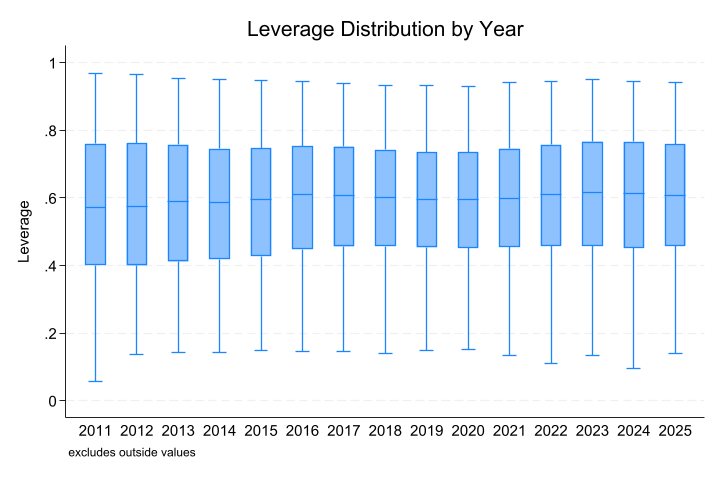

In [33]:

use "$CLEAN/final_panel.dta", clear

* 描述性统计（分三组）—— 保持不变
eststo clear
estpost sum lev npr size tang growth ndts
eststo full
estpost sum lev npr size tang growth ndts if soe == 1
eststo soe
estpost sum lev npr size tang growth ndts if soe == 0
eststo nonsoe

esttab full soe nonsoe using "$OUT/desc_summary.rtf", ///
    cells("mean(fmt(3)) sd(fmt(3)) p10(fmt(3)) p25(fmt(3)) p50(fmt(3)) p75(fmt(3)) p90(fmt(3))") ///
    nonumber mtitle("Full" "SOE" "Non-SOE") replace

* t 检验
foreach v in lev npr size tang growth ndts {
    ttest `v', by(soe)
}

* 相关系数矩阵（数值输出）
pwcorr lev npr size tang growth ndts soe, star(0.05) sig

* 绘制散点图矩阵（替代热力图）
graph matrix lev npr size tang growth ndts soe, ///
    half msymbol(circle_hollow) mcolor(blue%30) ///
    title("Scatterplot Matrix of Main Variables") ///
    note("Diagonal panels show variable names. Off-diagonal show pairwise scatter plots.")
graph export "$FIG/corr_scatter_matrix.png", replace

* 分年度时序图（原有代码继续）
preserve
collapse (mean) lev npr, by(year soe)
twoway (line lev year if soe==1, lcolor(blue) lpattern(solid)) ///
       (line lev year if soe==0, lcolor(red) lpattern(dash)), ///
       legend(label(1 "SOE") label(2 "Non-SOE")) ///
       title("Average Leverage by Year") ytitle("Leverage") xtitle("Year")
graph export "$FIG/lev_trend_by_soe.png", replace

twoway (line npr year if soe==1, lcolor(blue) lpattern(solid)) ///
       (line npr year if soe==0, lcolor(red) lpattern(dash)), ///
       legend(label(1 "SOE") label(2 "Non-SOE")) ///
       title("Average NPR by Year") ytitle("NPR") xtitle("Year")
graph export "$FIG/npr_trend_by_soe.png", replace
restore

* Lev 分年度箱线图
graph box lev, over(year) nooutsides ///
    title("Leverage Distribution by Year") ytitle("Leverage")
graph export "$FIG/lev_box_by_year.png", replace

(39,684 observations deleted)
(39,684 observations deleted)
(file ../output/figures/winsor_box_lev.png not found)
file ../output/figures/winsor_box_lev.png written in PNG format
(39,684 observations deleted)
(39,684 observations deleted)
(file ../output/figures/winsor_box_npr.png not found)
file ../output/figures/winsor_box_npr.png written in PNG format


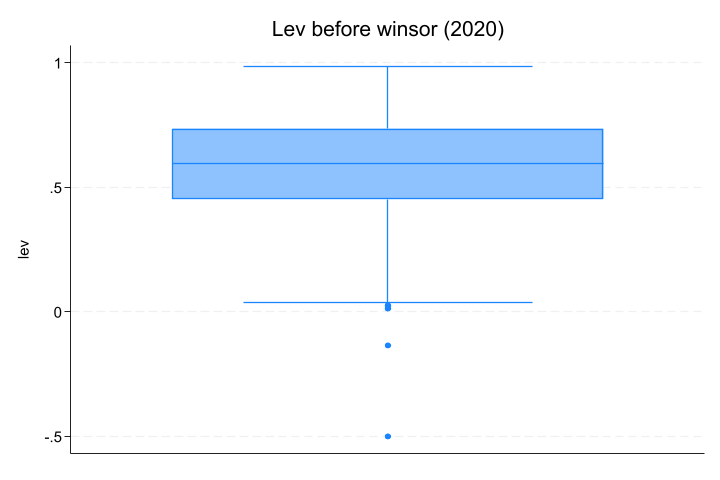

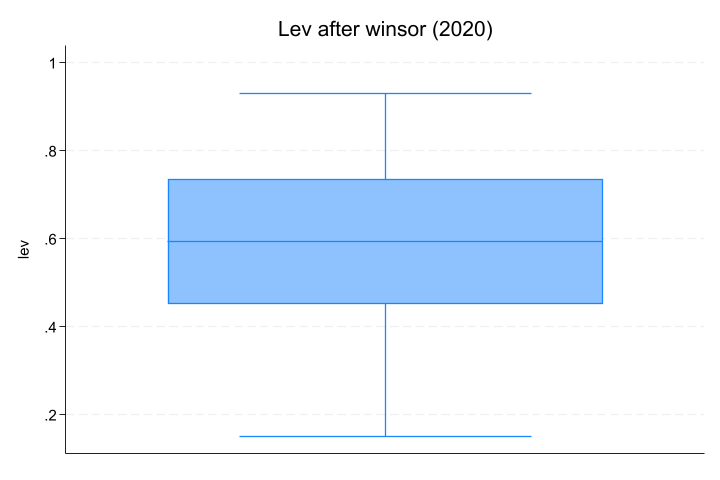

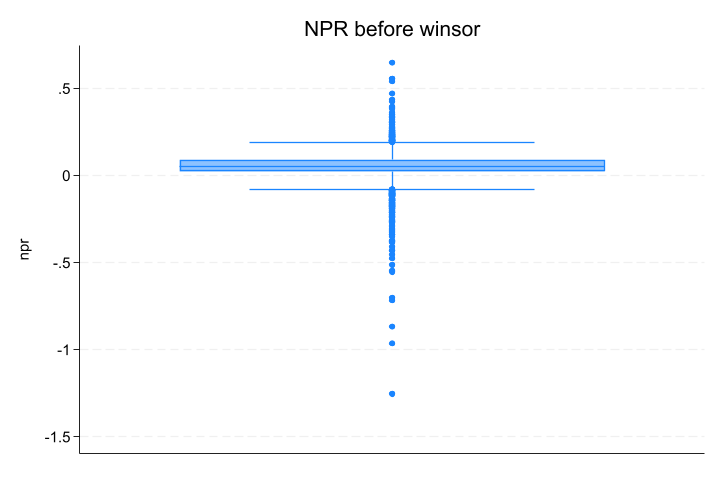

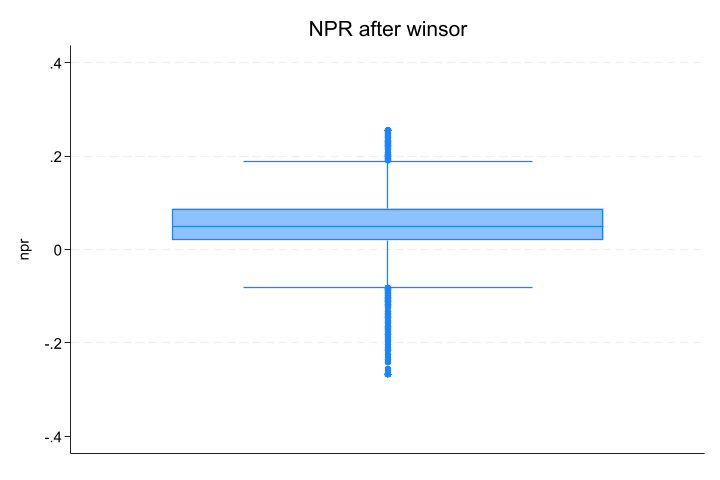

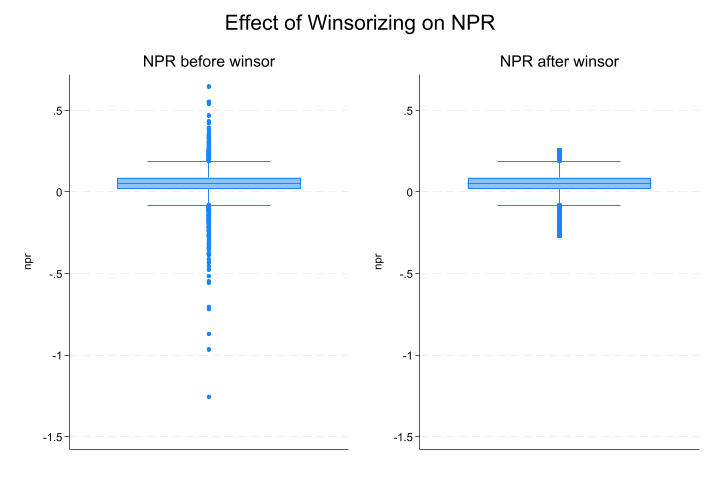

graph __00000D not found
r(111);


In [34]:

* 对比缩尾前后的分布（以 2020 年为例，也可选择其他年份）
use "$CLEAN/sample_before_winsor.dta", clear
keep if year == 2020
graph box lev, name(before_lev, replace) title("Lev before winsor (2020)")

use "$CLEAN/final_panel.dta", clear
keep if year == 2020
graph box lev, name(after_lev, replace) title("Lev after winsor (2020)")

graph combine before_lev after_lev, rows(1) ycommon title("Effect of Winsorizing on Leverage")
graph export "$FIG/winsor_box_lev.png", replace

* 可类似绘制 NPR
use "$CLEAN/sample_before_winsor.dta", clear
keep if year == 2020
graph box npr, name(before_npr, replace) title("NPR before winsor")

use "$CLEAN/final_panel.dta", clear
keep if year == 2020
graph box npr, name(after_npr, replace) title("NPR after winsor")

graph combine before_npr after_npr, rows(1) ycommon title("Effect of Winsorizing on NPR")
graph export "$FIG/winsor_box_npr.png", replace

In [63]:
ssc install ftools, replace
ssc install require, replace
ssc install regife, replace
ssc install reghdfe, replace
ssc install hdfe, replace

checking ftools consistency and verifying not already installed...

the following files will be replaced:
    C:\Users\Lenovo\ado\plus\f\ftools.ado
    C:\Users\Lenovo\ado\plus\f\ftools.sthlp
    C:\Users\Lenovo\ado\plus\m\ms_parse_vce.ado

installing into C:\Users\Lenovo\ado\plus\...
installation complete.
checking require consistency and verifying not already installed...
all files already exist and are up to date.
checking regife consistency and verifying not already installed...
all files already exist and are up to date.
checking reghdfe consistency and verifying not already installed...
all files already exist and are up to date.
checking hdfe consistency and verifying not already installed...
all files already exist and are up to date.



Panel variable: stkcd (unbalanced)
 Time variable: year, 2011 to 2025, but with gaps
         Delta: 1 unit
(dropped 223 singleton observations)
(MWFE estimator converged in 7 iterations)
> lbach & Miller applied.
> clusters

HDFE Linear regression                            Number of obs   =     42,803
Absorbing 2 HDFE groups                           F(   5,     14) =          .
Statistics robust to heteroskedasticity           Prob > F        =          .
                                                  R-squared       =     1.0000
                                                  Adj R-squared   =     1.0000
Number of clusters (stkcd)   =      4,686         Within R-sq.    =     1.0000
Number of clusters (year)    =         15         Root MSE        =     0.0002

                            (Std. err. adjusted for 15 clusters in stkcd year)
------------------------------------------------------------------------------
             |               Robust
         lev | Coefficien

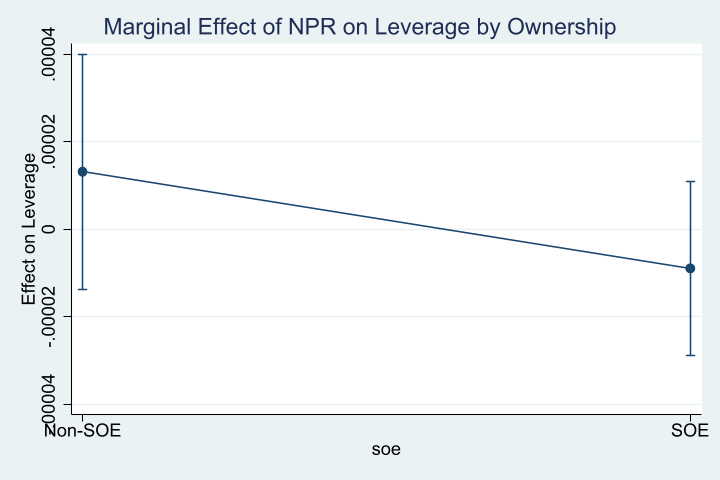

In [73]:

use "$CLEAN/final_panel.dta", clear
xtset stkcd year

global controls "size tang growth ndts"

* M1: 双向固定效应
reghdfe lev npr $controls, absorb(stkcd year) vce(cluster stkcd year)
estimates store M1

* M2a: 国有企业组
reghdfe lev npr $controls if soe == 1, absorb(stkcd year) vce(cluster stkcd year)
estimates store M2_soe

* M2b: 民营企业组
reghdfe lev npr $controls if soe == 0, absorb(stkcd year) vce(cluster stkcd year)
estimates store M2_nonsoe

* M3: 交互项调节效应 —— 用因子变量写法，让 margins 可以识别 soe
reghdfe lev c.npr##i.soe $controls, absorb(stkcd year) vce(cluster stkcd year)
estimates store M3

* 检验国有企业中 NPR 的总效应
lincom _b[npr] + _b[1.soe#c.npr]

* 绘制边际效应图
quietly margins, dydx(npr) at(soe=(0 1))
marginsplot, xlabel(0 "Non-SOE" 1 "SOE") ///
    title("Marginal Effect of NPR on Leverage by Ownership") ///
    ytitle("Effect on Leverage") ///
    scheme(s2color)
graph export "$FIG/M3_margins_soe.png", replace

In [ ]:

use "$CLEAN/final_panel.dta", clear

* 确保 m2_growth 变量存在
cap confirm variable m2_growth
if _rc {
    di "Error: m2_growth variable not found. Please merge m2 data first."
    exit
}

cap which regife
if _rc == 0 {
    regife lev npr m2_growth $controls, ife(stkcd year, 1)
    estimates store M1_ife
}
else {
    di "regife not installed. Skipping IFE model."
    estimates store M1_ife  // 创建一个空存储，避免后续表格出错
    capture estimates drop M1_ife
}

regife not installed. Skipping IFE model.



Panel variable: stkcd (unbalanced)
 Time variable: year, 2011 to 2025, but with gaps
         Delta: 1 unit
(dropped 223 singleton observations)
(MWFE estimator converged in 7 iterations)
> lbach & Miller applied.
> clusters

HDFE Linear regression                            Number of obs   =     42,803
Absorbing 2 HDFE groups                           F(  19,     14) =          .
Statistics robust to heteroskedasticity           Prob > F        =          .
                                                  R-squared       =     1.0000
                                                  Adj R-squared   =     1.0000
Number of clusters (stkcd)   =      4,686         Within R-sq.    =     1.0000
Number of clusters (year)    =         15         Root MSE        =     0.0002

                            (Std. err. adjusted for 15 clusters in stkcd year)
------------------------------------------------------------------------------
             |               Robust
         lev | Coefficien

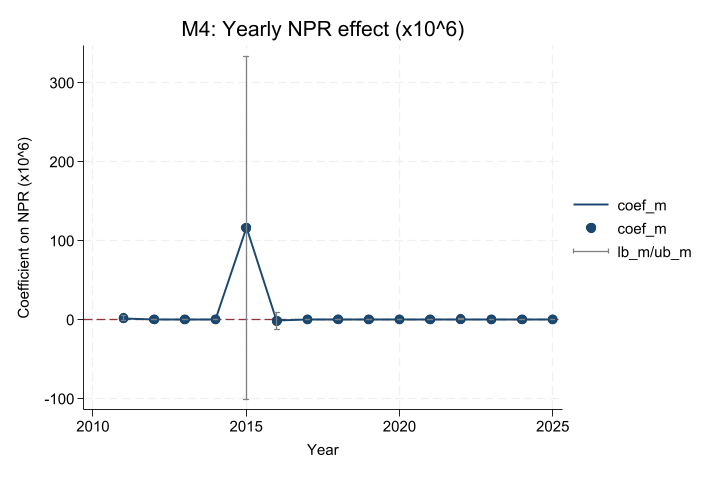

In [48]:

use "$CLEAN/final_panel.dta", clear
xtset stkcd year

* 方法1：使用 i.year#c.npr 交互项
reghdfe lev i.year#c.npr $controls, absorb(stkcd year) vce(cluster stkcd year)
estimates store M4

* 提取各年系数并绘图
coefplot, keep(*.year#c.npr) vertical recast(line) ///
    title("Time-varying Coefficient of NPR (95% CI)") ///
    xtitle("Year") ytitle("Coefficient") ///
    xlabel(, angle(45)) ciopts(recast(rcap))
graph export "$FIG/M4_timevary_coefs.png", replace

* 备选：若 coefplot 提取困难，使用手动循环输出
levelsof year, local(yrs)
tempname f_m4
postfile `f_m4' int year double coef se using "$OUT/m4_year_coefs.dta", replace
foreach y of local yrs {
    capture noisily count if year == `y'
    if r(N) >= 20 {
        capture noisily regress lev npr $controls if year == `y', vce(robust)
        if _rc == 0 & !missing(_b[npr]) {
            post `f_m4' (`y') (_b[npr]) (_se[npr])
        }
    }
}
postclose `f_m4'
use "$OUT/m4_year_coefs.dta", clear
gen coef_m = coef * 1000000
gen lb_m = (coef - 1.96*se) * 1000000
gen ub_m = (coef + 1.96*se) * 1000000
count if !missing(coef_m)
di as txt "Non-missing M4 points = " r(N)
sum coef_m, meanonly
local ymin = r(min)
local ymax = r(max)
local pad = max(1, (`ymax' - `ymin') * 0.15)
local ymin = `ymin' - `pad'
local ymax = `ymax' + `pad'
twoway (line coef_m year, lcolor(navy) lwidth(medthick)) ///
       (scatter coef_m year, mcolor(navy) msymbol(O) msize(medlarge)) ///
       (rcap lb_m ub_m year, lcolor(gs8)), ///
       yline(0, lpattern(dash) lcolor(maroon)) ///
       yscale(range(`ymin' `ymax')) ///
       title("M4: Yearly NPR effect (x10^6)") ytitle("Coefficient on NPR (x10^6)") xtitle("Year")
graph export "$FIG/M4_timevary_coefs_alt.png", replace


Panel variable: stkcd (unbalanced)
 Time variable: year, 2011 to 2025, but with gaps
         Delta: 1 unit
(dropped 223 singleton observations)
(MWFE estimator converged in 7 iterations)
> lbach & Miller applied.
> clusters

HDFE Linear regression                            Number of obs   =     42,803
Absorbing 2 HDFE groups                           F(   7,     14) =          .
Statistics robust to heteroskedasticity           Prob > F        =          .
                                                  R-squared       =     1.0000
                                                  Adj R-squared   =     1.0000
Number of clusters (stkcd)   =      4,686         Within R-sq.    =     1.0000
Number of clusters (year)    =         15         Root MSE        =     0.0002

                            (Std. err. adjusted for 15 clusters in stkcd year)
------------------------------------------------------------------------------
             |               Robust
         lev | Coefficien

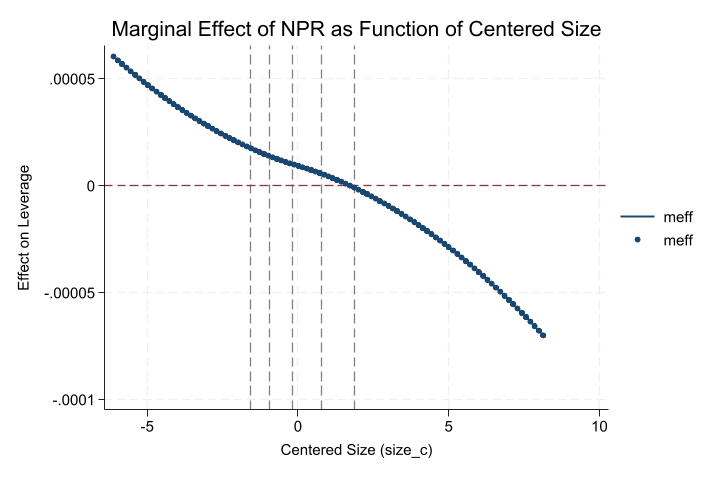

In [52]:

use "$CLEAN/final_panel.dta", clear
xtset stkcd year

* 中心化 Size 以减少共线性
sum size, meanonly
gen size_c = size - r(mean)

gen npr_size = npr * size_c
gen npr_size2 = npr * size_c^2

reghdfe lev npr npr_size npr_size2 $controls, absorb(stkcd year) vce(cluster stkcd year)
estimates store M5

* 绘制 β(Size) 函数图
sum size_c, detail
local sz_min = r(min)
local sz_max = r(max)
local p10 = r(p10)
local p25 = r(p25)
local p50 = r(p50)
local p75 = r(p75)
local p90 = r(p90)

tempfile beta_curve
tempname fh2
postfile `fh2' double size_c meff using `beta_curve', replace
forvalues k = 0(1)100 {
    local s = `sz_min' + (`sz_max' - `sz_min') * `k' / 100
    local me = _b[npr] + _b[npr_size]*`s' + _b[npr_size2]*(`s'^2)
    post `fh2' (`s') (`me')
}
postclose `fh2'
use `beta_curve', clear
twoway (line meff size_c, lcolor(navy) lwidth(medthick)) ///
       (scatter meff size_c, mcolor(navy) msymbol(O) msize(small)) ///
       , yline(0, lpattern(dash) lcolor(maroon)) ///
       xline(`p10' `p25' `p50' `p75' `p90', lpattern(dash) lcolor(gs8)) ///
       title("Marginal Effect of NPR as Function of Centered Size") ///
       xtitle("Centered Size (size_c)") ytitle("Effect on Leverage")
graph export "$FIG/M5_beta_size_function.png", replace


Panel variable: stkcd (unbalanced)
 Time variable: year, 2011 to 2025, but with gaps
         Delta: 1 unit
Running threshold grid search for M6.
(file C:\Users\Lenovo\AppData\Local\Temp\ST_3004_00002u.tmp not found)

                                                          Binom. interp.   
    Variable |       Obs  Percentile    Centile        [95% conf. interval]
-------------+-------------------------------------------------------------
        size |    43,026         10    20.66213        20.64762    20.67737
             |                   15    20.90544        20.89167    20.92062
             |                   20    21.10636        21.09183     21.1216
             |                   25    21.28218        21.26851    21.29687
             |                   30    21.44385        21.43272    21.45655
             |                   35    21.59899        21.58412    21.61313
             |                   40    21.74763         21.7344    21.76216
             |       

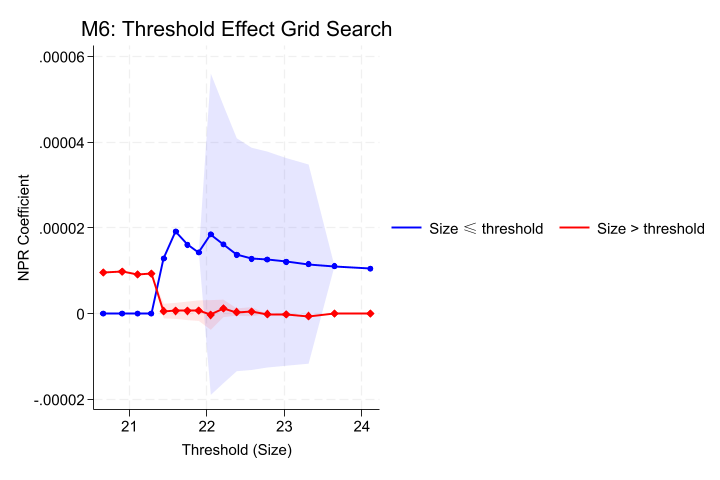

In [55]:

use "$CLEAN/final_panel.dta", clear
xtset stkcd year

* 备选：网格搜索门槛效应（保证可画出多点图）
di "Running threshold grid search for M6."
tempfile m6grid
tempname f_m6
postfile `f_m6' double th str6 group double coef se long N using `m6grid', replace

* 使用分位数阈值；若双向聚类失败则回退到 robust
centile size, centile(10 15 20 25 30 35 40 45 50 55 60 65 70 75 80 85 90)
local t1 = r(c_1)
local t2 = r(c_2)
local t3 = r(c_3)
local t4 = r(c_4)
local t5 = r(c_5)
local t6 = r(c_6)
local t7 = r(c_7)
local t8 = r(c_8)
local t9 = r(c_9)
local t10 = r(c_10)
local t11 = r(c_11)
local t12 = r(c_12)
local t13 = r(c_13)
local t14 = r(c_14)
local t15 = r(c_15)
local t16 = r(c_16)
local t17 = r(c_17)
local thresholds "`t1' `t2' `t3' `t4' `t5' `t6' `t7' `t8' `t9' `t10' `t11' `t12' `t13' `t14' `t15' `t16' `t17'"
foreach th of local thresholds {
    foreach grp in low high {
        local cond = cond("`grp'" == "low", "size <= `th'", "size > `th'")
        capture noisily reghdfe lev npr $controls if `cond', absorb(stkcd year) vce(cluster stkcd year)
        if _rc != 0 capture noisily regress lev npr $controls if `cond', vce(robust)
        if _rc == 0 & e(N) >= 20 {
            post `f_m6' (`th') ("`grp'") (_b[npr]) (_se[npr]) (e(N))
        }
    }
}
postclose `f_m6'

use `m6grid', clear
drop if missing(th, coef, se)
count
di as txt "M6 points kept = " r(N)
gen lb = coef - 1.96*se
gen ub = coef + 1.96*se
sort group th
twoway (rarea lb ub th if group=="low", color(blue%12) lcolor(blue%0)) ///
       (line coef th if group=="low", lcolor(blue) lwidth(medthick)) ///
       (scatter coef th if group=="low", mcolor(blue) msymbol(O) msize(small)) ///
       (rarea lb ub th if group=="high", color(red%12) lcolor(red%0)) ///
       (line coef th if group=="high", lcolor(red) lwidth(medthick)) ///
       (scatter coef th if group=="high", mcolor(red) msymbol(D) msize(small)) ///
       , legend(order(2 "Size ≤ threshold" 5 "Size > threshold") rows(1)) ///
       xtitle("Threshold (Size)") ytitle("NPR Coefficient") ///
       title("M6: Threshold Effect Grid Search")
graph export "$FIG/M6_threshold_grid.png", replace
export delimited using "$OUT/m6_threshold_grid.csv", replace

In [74]:

use "$CLEAN/final_panel.dta", clear

* 确保各模型已存储
cap estimates restore M1
cap estimates restore M1_ife
cap estimates restore M2_soe
cap estimates restore M2_nonsoe
cap estimates restore M3

* 输出表格
local stats_opts stats(N r2_within N_clust1, fmt(%9.0f %9.3f %9.0f) ///
         labels("Observations" "Within R2" "Firms"))

* 判断 M1_ife 是否存在
local has_ife = 0
cap estimates restore M1_ife
if _rc == 0 local has_ife = 1

if `has_ife' == 1 {
    esttab M1 M1_ife M2_soe M2_nonsoe M3 using "$OUT/reg_results_M1_M3.rtf", ///
        replace se star(* 0.1 ** 0.05 *** 0.01) ///
        keep(npr npr_soe m2_growth size tang growth ndts) ///
        order(npr npr_soe m2_growth size tang growth ndts) ///
        `stats_opts' ///
        title("Regression Results: Determinants of Leverage") ///
        addnotes("Standard errors clustered by firm and year (M1_ife uses robust)." ///
                 "SOE dummy absorbed in fixed-effects models.")
}
else {
    esttab M1 M2_soe M2_nonsoe M3 using "$OUT/reg_results_M1_M3.rtf", ///
        replace se star(* 0.1 ** 0.05 *** 0.01) ///
        keep(npr npr_soe size tang growth ndts) ///
        order(npr npr_soe size tang growth ndts) ///
        `stats_opts' ///
        title("Regression Results: Determinants of Leverage") ///
        addnotes("Standard errors clustered by firm and year." ///
                 "SOE dummy absorbed in fixed-effects models.")
}

* 同时输出 CSV
esttab M1 M2_soe M2_nonsoe M3 using "$OUT/reg_results_M1_M3.csv", replace se star

(output written to ../output/reg_results_M1_M3.rtf)
(output written to ../output/reg_results_M1_M3.csv)


In [57]:

di as result _n "========================================="
di as result "All analysis completed successfully!"
di as result "Check output folder: $OUT"
di as result "Figures folder: $FIG"
di as result "========================================="


All analysis completed successfully!
Check output folder: ../output
Figures folder: ../output/figures
